# Versoix model

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import geone
import geone.covModel as gcm
import os
import sys
import pyvista as pv
import pandas as pd

archpy_path = "C:/Users/Margaux/ArchPy/" #Set path to ArchPy

try:
    import ArchPy
except: # if ArchPy is not installed
    print("ArchPy not installed")
    sys.path.append(f"{archpy_path}")
    import ArchPy

ArchPy not installed


In [2]:
T1 = ArchPy.base.Arch_table(name = "Versoix_model", seed = 64, verbose = 2)

In [3]:
X0 = 2499498 #Model x0 coordinate 
Y0 = 1125350 #Model y0 coordinate 
X1 = 2502460 # 2'962 m
Y1 = 1128167 # 2'817 m

In [4]:
#Grid
res_fac = 2

nx = int(300/res_fac) #Nb of cells
ny = int(280/res_fac)
#nz = int(150/res_fac)
nz = 150
sx = 2962/nx #Cells width (can be floats)
sy = 2817/ny
sz = 150/nz
ox = 2499498 # Coos of origin
oy = 1125350
oz = 300
dimensions = (nx, ny, nz)
spacing = (sx, sy, sz)
origin = (ox, oy, oz)

#T1.add_grid(dimensions, spacing, origin, top="data_folder/topo_versoix_new.tif", bot="data_folder/TOIT_MOLASSE.tif")
#T1.add_grid(dimensions, spacing, origin, top="data_folder/MNT_test.grd", bot="data_folder/TOIT_MOLASSE_test.grd",polygon="C:/Users/Margaux/OneDrive - unine.ch/Documents/Unine/Master Thesis/4. Modflow model/example_modelregional/data_folder_versoix_sector/Versoix_riv_sector.shp")
T1.add_grid(dimensions, spacing, origin, top="data_folder/MNT_Versoix.tif", bot="data_folder/TOP_MOL_Versoix.tif",polygon="data_folder/Versoix_riv_sector.shp")
#T1.add_grid(dimensions, spacing, origin)

## Adding Grid ##
Top is a raster - resampling activated
Bot is a raster - resampling activated
Polygon is a shapely instance - discretization activated
## Grid added and is now simulation grid ##


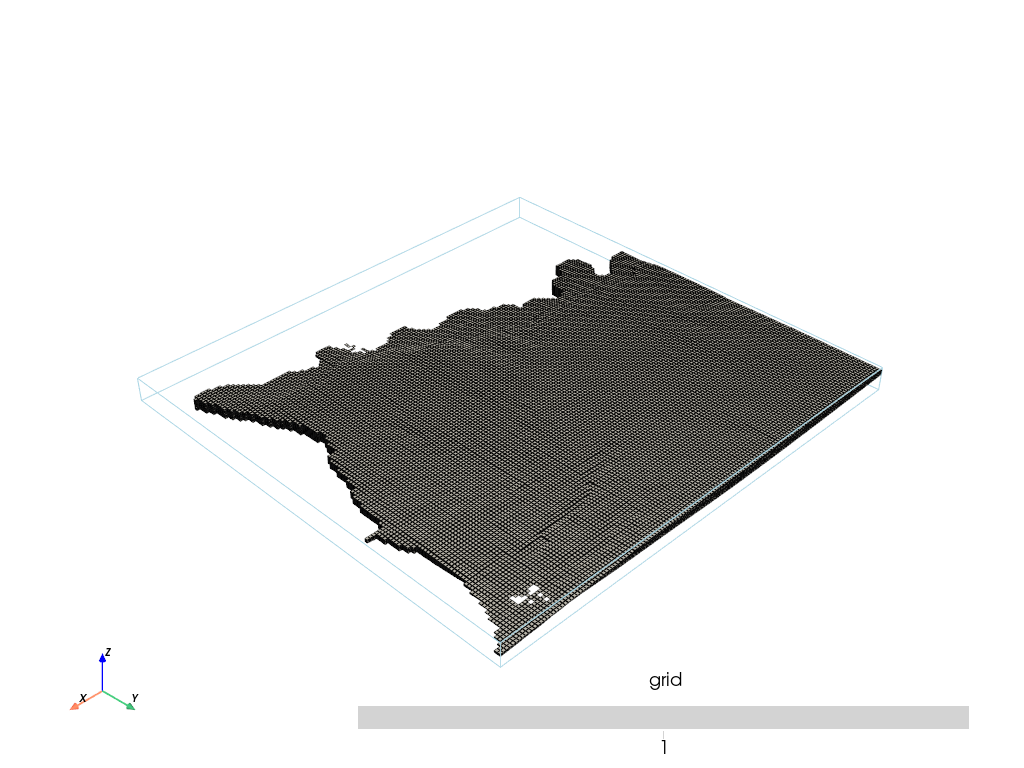

In [5]:
pv.set_jupyter_backend('static')
T1.plot_grid()

In [6]:
P1 = ArchPy.base.Pile("Pile_1")
T1.set_Pile_master(P1)

Pile sets as Pile master


In [7]:
#path to the files
folder = "data_folder"
l_bh_path = pd.read_csv(os.path.join(folder, "versoix_bh.lbh"), sep=';')

unit_data_path = pd.read_csv(os.path.join(folder, "versoix_bh.ud"), sep=';')

facies_data_path = pd.read_csv(os.path.join(folder, "versoix_bh.fd"), sep=';')

In [8]:
#import data
db, l_bhs = ArchPy.inputs.load_bh_files(list_bhs=l_bh_path, 
                            units_data=unit_data_path,
                            facies_data=facies_data_path, altitude=True)
db #print database

Top altitude of first facies (386.7) does not match borehole (19335.0) altitude (350.7), altitudes modified.

Gap encountered - creation of a gap interval
Gap encountered - creation of a gap interval
Gap encountered - creation of a gap interval
Gap encountered - creation of a gap interval
Gap encountered - creation of a gap interval
Top altitude of first facies (423.0) does not match borehole (19610.0) altitude (381.0), altitudes modified.

Gap encountered - creation of a gap interval
Gap encountered - creation of a gap interval
Top altitude of first unit (388.23) does not match borehole (8834.0) altitude (387.23), altitudes modified.

Gap encountered - creation of a gap interval
Top altitude of first facies (403.0) does not match borehole (16434.0) altitude (349.0), altitudes modified.

Gap encountered - creation of a gap interval
Top altitude of first unit (403.0) does not match borehole (16434.0) altitude (399.0), altitudes modified.

Gap encountered - creation of a gap interval
Top

,Strat_ID,Facies_ID,top,bot
bh_ID,,,,
19444.0,u3,ab,373.6,373.40
19444.0,u3,a,373.4,372.60
19444.0,u3,b,372.6,364.40
19444.0,u3,bc,364.4,357.40
19444.0,u3,d,357.4,357.40
...,...,...,...,...
24750.0,u3,None,375.6,372.00
24750.0,u7,None,372.0,371.95
24749.0,u3,None,376.1,374.50


In [9]:
l_bhs

,bh_x,bh_y,bh_z,bh_depth
bh_ID,,,,
19444.0,2502190.00,1125450.00,373.60,17.00
18793.0,2502144.70,1127037.50,376.25,7.00
19110.0,2501838.00,1127336.00,391.90,10.00
18033.0,2500052.00,1126270.00,395.10,10.00
18034.0,2499937.00,1126198.00,400.70,9.00
...,...,...,...,...
24330.0,2501894.86,1125839.09,381.68,20.00
24713.0,2502136.00,1127106.00,381.07,180.00
24714.0,2502136.16,1127096.79,381.00,180.00


In [10]:
runned = False

In [11]:
def estimate_SIS_covmodel(unit, arch_table, facies, covmodel, ncla, cm_fitted_3D=None, iu=0, ndata_min = 100,
                          ignore_factor = 1, hmax=np.nan, bounds=(), plot_varExp=True, alpha_loc_func = None,
                            **kwargs):
    """
    Estimate a 3D indicator covmodel according to data of a facies
    kwargs : arguments for variogramExp3D
    """
    kwargs_def = {"tol_dist":(10, 10, 5), "tol_angle":(45, 45, 10), "hmax_var" : (hmax, hmax, hmax),
    "ncla" : (ncla, ncla, ncla), "cla_center" : (None, None, None), "cla_length" : (None, None, None)}

    for k, val in kwargs_def.items():
        if k not in kwargs.keys():
            kwargs[k] = val
            
    #first get x position and indicator values (0 or 1)
    x_pos,v = get_Ivalues(arch_table, unit, facies, iu)
    ndata = len(v)

    if ignore_factor > 1:
        ndata_to_keep = 1/ignore_factor * ndata
        ind = np.random.choice(np.arange(ndata),size=ndata_to_keep)
        x_pos = x_pos[ind]
        v = v[ind]

    if ndata < ndata_min:
        print("Too few points")
        return None
        
    #2nd estimate covmodel
    if not plot_varExp:
        make_plot = True
        
    # cm_fitted_3D, popt = gcm.covModel3D_fit(x_pos,np.array(v),covmodel,make_plot=False,
    #                                     bounds = bounds,hmax = hmax, alpha_loc_func = alpha_loc_func)

    #plot to validate
    if plot_varExp:
        (hexp1, gexp1, cexp1),(hexp2, gexp2, cexp2),(hexp3, gexp3, cexp3) = gcm.variogramExp3D(x_pos,v,
                                                                                               alpha=cm_fitted_3D.alpha,
                                                                                               beta=cm_fitted_3D.beta,
                                                                                               gamma=cm_fitted_3D.gamma,
                                                                                tol_dist=kwargs["tol_dist"],tol_angle=kwargs["tol_angle"],
                                                                                               make_plot=False,hmax = kwargs["hmax_var"],ncla = kwargs["ncla"],
                                                                                               cla_length = kwargs["cla_length"], cla_center = kwargs["cla_center"],
                                                                                               alpha_loc_func = alpha_loc_func)
        
        plt.subplots(1,3,figsize=(16,8))
        plt.suptitle(f'Unit: {str(unit)}, facies: {str(facies)}')
        
        plt.subplot(1,3,1)
        geone.covModel.plot_variogramExp1D(hexp1, gexp1, cexp1, c='red', label='vario exp')
        cm_fitted_3D.plot_model_one_curve(vario=True, main_axis=1, hmax=0.8*np.nanmax(hexp1), c='red', label='vario opt')
        plt.legend()
        plt.title("along x'''")

        plt.subplot(1,3,2)
        geone.covModel.plot_variogramExp1D(hexp2, gexp2, cexp2, c='green', label='vario exp')
        cm_fitted_3D.plot_model_one_curve(vario=True, main_axis=2, hmax=0.8*np.nanmax(hexp2), c='green', label='vario opt')
        plt.legend()
        plt.ylabel(' ')
        plt.title("along y'''")

        plt.subplot(1,3,3)
        geone.covModel.plot_variogramExp1D(hexp3, gexp3, cexp3, c='blue', label='vario exp')
        cm_fitted_3D.plot_model_one_curve(vario=True, main_axis=3, hmax=0.8*np.nanmax(hexp3), c='blue', label='vario opt')
        plt.legend()
        plt.title("along z'''")
        plt.ylabel(' ')
        plt.show()
        
    return cm_fitted_3D

In [12]:
if runned == True :
    
    unit_cal = U3
    facies_cal = ac

    plt.rc('font', size=18) #controls default text size
    plt.rc('axes', titlesize=22) #fontsize of the title
    plt.rc('axes', labelsize=18) #fontsize of the x and y labels
    plt.rc('xtick', labelsize=20) #fontsize of the x tick labels
    plt.rc('ytick', labelsize=20) #fontsize of the y tick labels
    plt.rc('legend', fontsize=18) #fontsize of the legend
    
    x_pos,v = get_Ivalues(T1, unit_cal, facies_cal, 0)
    p = np.mean(v)

    #cm_fitted_3D = gcm.CovModel3D(elem=[ ('spherical', {'w':0.25, 'r':[1000,400,10]}), ('nugget', {'w':0})]) #abLR
    
    #cm_fitted_3D = gcm.CovModel3D(elem=[ ('spherical', {'w':0.13, 'r':[40,40,20]}), ('nugget', {'w':0})]) # abSR
    #cm_fitted_3D = gcm.CovModel3D(elem=[ ('spherical', {'w':0.23, 'r':[80,70,25]}), ('nugget', {'w':0})]) #a
    #cm_fitted_3D = gcm.CovModel3D(elem=[ ('spherical', {'w':0.09, 'r':[80,60,15]}), ('nugget', {'w':0})]) #b
    #cm_fitted_3D = gcm.CovModel3D(elem=[ ('spherical', {'w':0.25, 'r':[70,50,15]}), ('nugget', {'w':0})]) #ab
    cm_fitted_3D = gcm.CovModel3D(elem=[ ('spherical', {'w':0.07, 'r':[50,50,15]}), ('nugget', {'w':0})]) #ac

    print(p*(1-p))
    #cm_fitted_3D = gcm.CovModel3D(elem=[ ('cubic', {'w':p*(1-p), 'r':[300,300,15]}), ('nugget', {'w':0.01})])
    estimate_SIS_covmodel(unit=unit_cal, arch_table=T1, facies=facies_cal, covmodel=cm_prop, cm_fitted_3D=cm_fitted_3D, hmax=200, ncla=15)
    plt.show()
    #Mettre petit hmax, faire un premier fit, puis augmenter hmax

### 

In [13]:
#Unit 1 - Version 6 - long range
covmodel_SIS = gcm.CovModel3D(elem = [("spherical", {"w":2, "r":[20,20,5]}), ("exponential", {"w":1, "r":[30,30,5]})])
cm_fitted_3D_1 = gcm.CovModel3D(elem=[ ('spherical', {'w':0.08, 'r':[15,15,15]}), ('nugget', {'w':0.01})]) #Soil
cm_fitted_3D_2 = gcm.CovModel3D(elem=[ ('spherical', {'w':0.16, 'r':[15,15,15]}), ('nugget', {'w':0.025})]) #a
cm_fitted_3D_3 = gcm.CovModel3D(elem=[ ('spherical', {'w':0.12, 'r':[15,15,15]}), ('nugget', {'w':0})]) #b
cm_fitted_3D_3_ab = gcm.CovModel3D(elem=[ ('spherical', {'w':0.12, 'r':[15,15,15]}), ('nugget', {'w':0})]) #ab
cm_fitted_3D_4 = gcm.CovModel3D(elem=[ ('spherical', {'w':0.15, 'r':[15,15,15]}), ('nugget', {'w':0})]) #c
cm_fitted_3D_5 = gcm.CovModel3D(elem=[ ('spherical', {'w':0.11, 'r':[15,15,15]}), ('nugget', {'w':0.02})]) #d
cm_fitted_3D_6 = gcm.CovModel3D(elem=[ ('spherical', {'w':0.09, 'r':[15,15,15]}), ('nugget', {'w':0})]) #e
cm_fitted_3D_7 = gcm.CovModel3D(elem=[ ('spherical', {'w':0.08, 'r':[15,15,15]}), ('nugget', {'w':0.01})]) #ac
cm_fitted_3D_8 = gcm.CovModel3D(elem=[ ('spherical', {'w':0.10, 'r':[15,15,15]}), ('nugget', {'w':0})]) #bc

dic_facies_u1 = {"f_method" : "SIS", "f_covmodel" : [cm_fitted_3D_1, cm_fitted_3D_2, cm_fitted_3D_3, cm_fitted_3D_4, cm_fitted_3D_5, cm_fitted_3D_6, cm_fitted_3D_3_ab, cm_fitted_3D_7, cm_fitted_3D_8], "probability" : [0.108, 0.180, 0.104, 0.110, 0.1, 0.063, 0.172, 0.07, 0.093]} 
# Peut être une liste de la longueur du nb de facies dans l'unité défini en dessous

U1 = ArchPy.base.Unit(name = "u3", order = 1, color = "saddlebrown", surface = ArchPy.base.Surface(), ID = 1, dic_facies=dic_facies_u1)

#Unit 2
#covmodel_S2 = gcm.CovModel2D(elem = [("cubic", {"w":1, "r":[25,35]})])
#dic_surf_s2 = {"covmodel":covmodel_S2, "int_method" : "grf_ineq"}
#S2 = ArchPy.base.Surface(name = "S1", dic_surf=dic_surf_s2)
#dic_facies_u2 = {"f_method" : "SIS", "f_covmodel" : covmodel_SIS}
#U2 = ArchPy.base.Unit(name = "2", order = 2, color = "whitesmoke", surface = S2, ID = 2, dic_facies=dic_facies_u2)

#Unit 2
covmodel_S2 = gcm.CovModel2D(elem = [("cubic", {"w":1, "r":[25,35]})])
dic_surf_s2 = {"covmodel":covmodel_S2, "int_method" : "grf_ineq"}
S2 = ArchPy.base.Surface(name = "S1", dic_surf=dic_surf_s2,contact='erode')

cm_fitted_3D_9 = gcm.CovModel3D(elem=[ ('spherical', {'w':0.15, 'r':[100,75,10]}), ('nugget', {'w':0})]) #a
cm_fitted_3D_10 = gcm.CovModel3D(elem=[ ('spherical', {'w':0.06, 'r':[100,75,10]}), ('nugget', {'w':0})]) #b
cm_fitted_3D_11 = gcm.CovModel3D(elem=[ ('spherical', {'w':0.12, 'r':[100,75,10]}), ('nugget', {'w':0})]) #c
cm_fitted_3D_12 = gcm.CovModel3D(elem=[ ('spherical', {'w':0.16, 'r':[100,75,10]}), ('nugget', {'w':0})]) #d
cm_fitted_3D_13 = gcm.CovModel3D(elem=[ ('spherical', {'w':0.08, 'r':[100,75,10]}), ('nugget', {'w':0})]) #e
cm_fitted_3D_14 = gcm.CovModel3D(elem=[ ('spherical', {'w':0.13, 'r':[100,75,10]}), ('nugget', {'w':0})]) #ab
cm_fitted_3D_15 = gcm.CovModel3D(elem=[ ('spherical', {'w':0.14, 'r':[100,75,10]}), ('nugget', {'w':0})]) #bc

dic_facies_u2 = {"f_method" : "SIS", "f_covmodel" : [cm_fitted_3D_9, cm_fitted_3D_10, cm_fitted_3D_11, cm_fitted_3D_12, cm_fitted_3D_13, cm_fitted_3D_14, cm_fitted_3D_15], "probability" : [0.172, 0.072, 0.156, 0.229, 0.091, 0.118, 0.162]}

U2 = ArchPy.base.Unit(name = "u7", order = 2, color = "gold", surface = S2, ID = 2, dic_facies=dic_facies_u2)

#Unit 3
covmodel_S3 = gcm.CovModel2D(elem = [("cubic", {"w":1, "r":[25,35]})])
dic_surf_s3 = {"covmodel":covmodel_S3, "int_method" : "grf_ineq"}
S3 = ArchPy.base.Surface(name = "S2", dic_surf=dic_surf_s3,contact='erode')

cm_fitted_3D_16 = gcm.CovModel3D(elem=[ ('spherical', {'w':0.23, 'r':[650,200,10]}), ('nugget', {'w':0})]) #a
cm_fitted_3D_17 = gcm.CovModel3D(elem=[ ('spherical', {'w':0.09, 'r':[1500,625,15]}), ('nugget', {'w':0})]) #b
cm_fitted_3D_19 = gcm.CovModel3D(elem=[ ('spherical', {'w':0.25, 'r':[1000,400,10]}), ('nugget', {'w':0})]) #ab
cm_fitted_3D_20 = gcm.CovModel3D(elem=[ ('spherical', {'w':0.07, 'r':[800,215,10]}), ('nugget', {'w':0})]) #ac
#'r':[200,175,15]

dic_facies_u3 = {"f_method" : "SIS", "f_covmodel" : [cm_fitted_3D_16, cm_fitted_3D_17, cm_fitted_3D_19, cm_fitted_3D_20], "probability" : [0.343, 0.087, 0.482, 0.088]}

U3 = ArchPy.base.Unit(name = "u9", order = 3, color = "coral", surface = S3, ID = 3, dic_facies=dic_facies_u3)

#Unit 4
covmodel_S4 = gcm.CovModel2D(elem = [("cubic", {"w":1, "r":[25,35]})])
dic_surf_s4 = {"covmodel":covmodel_S4, "int_method" : "grf_ineq"}
S4 = ArchPy.base.Surface(name = "S3", dic_surf=dic_surf_s4,contact='erode')

cm_fitted_3D_21 = gcm.CovModel3D(elem=[ ('spherical', {'w':0.12, 'r':[100,75,10]}), ('nugget', {'w':0})]) #a
cm_fitted_3D_22 = gcm.CovModel3D(elem=[ ('spherical', {'w':0.1, 'r':[100,75,10]}), ('nugget', {'w':0})]) #b
cm_fitted_3D_23 = gcm.CovModel3D(elem=[ ('spherical', {'w':0.12, 'r':[100,75,10]}), ('nugget', {'w':0})]) #c 
cm_fitted_3D_24 = gcm.CovModel3D(elem=[ ('spherical', {'w':0.25, 'r':[100,75,10]}), ('nugget', {'w':0})]) #d
cm_fitted_3D_25 = gcm.CovModel3D(elem=[ ('spherical', {'w':0.1, 'r':[100,75,10]}), ('nugget', {'w':0})]) #bc


dic_facies_u4 = {"f_method" : "SIS", "f_covmodel" : [cm_fitted_3D_21, cm_fitted_3D_22, cm_fitted_3D_23, cm_fitted_3D_24, cm_fitted_3D_25], "probability" : [0.073, 0.171, 0.134, 0.533, 0.089]}

U4 = ArchPy.base.Unit(name = "u12", order = 4, color = "royalblue", surface = S4, ID = 4, dic_facies=dic_facies_u4)

#Unit 5
covmodel_S5 = gcm.CovModel2D(elem = [("cubic", {"w":1, "r":[25,35]})])
dic_surf_s5 = {"covmodel":covmodel_S5, "int_method" : "grf_ineq"}
S5 = ArchPy.base.Surface(name = "S4", dic_surf=dic_surf_s5,contact='erode')

dic_facies_u5 = {"f_method" : "homogenous"}

U5 = ArchPy.base.Unit(name = "u14", order = 5, color = "lime", surface = S5, ID = 5, dic_facies=dic_facies_u5)


#Unit 9
#covmodel_S9 = gcm.CovModel2D(elem = [("cubic", {"w":1, "r":[25,35]})])
#dic_surf_s9 = {"covmodel":covmodel_S9, "int_method" : "grf_ineq"}
#S9 = ArchPy.base.Surface(name = "S8", dic_surf=dic_surf_s9)
#dic_facies_u9 = {"f_method" : "SIS", "f_covmodel" : covmodel_SIS}
#U9 = ArchPy.base.Unit(name = "15", order = 9, color = "cyan", surface = S9, ID = 9, dic_facies=dic_facies_u9)

P1.add_unit([U1, U2, U3, U4, U5])

Unit u3: Surface added for interpolation
Unit u7: Surface added for interpolation
Unit u9: Surface added for interpolation
Unit u12: Surface added for interpolation
Unit u14: Surface added for interpolation
Stratigraphic unit u3 added
Stratigraphic unit u7 added
Stratigraphic unit u9 added
Stratigraphic unit u12 added
Stratigraphic unit u14 added


In [14]:
Soil = ArchPy.base.Facies(ID = 1, name = "Soil", color = "black")
a = ArchPy.base.Facies(ID = 3, name = "a", color = "pink")
ab = ArchPy.base.Facies(ID = 4, name = "ab", color = "y")
ac = ArchPy.base.Facies(ID = 5, name = "ac", color = "gold")
b = ArchPy.base.Facies(ID = 7, name = "b", color = "lightyellow")
bc = ArchPy.base.Facies(ID = 8, name = "bc", color = "coral")
c = ArchPy.base.Facies(ID = 9, name = "c", color = "red")
d = ArchPy.base.Facies(ID = 11, name = "d", color = "cyan")
e = ArchPy.base.Facies(ID = 13, name = "e", color = "blue")
Molasse = ArchPy.base.Facies(ID = 14, name = "Molasse", color = "brown")

U1.add_facies([Soil,a,b,c,d,e,ab,ac,bc])
U2.add_facies([a,b,c,d,e,ab,bc])
U3.add_facies([a,b,ab,ac])
U4.add_facies([a,b,c,d,bc])
U5.add_facies([Molasse])

Facies Soil added to unit u3
Facies a added to unit u3
Facies b added to unit u3
Facies c added to unit u3
Facies d added to unit u3
Facies e added to unit u3
Facies ab added to unit u3
Facies ac added to unit u3
Facies bc added to unit u3
Facies a added to unit u7
Facies b added to unit u7
Facies c added to unit u7
Facies d added to unit u7
Facies e added to unit u7
Facies ab added to unit u7
Facies bc added to unit u7
Facies a added to unit u9
Facies b added to unit u9
Facies ab added to unit u9
Facies ac added to unit u9
Facies a added to unit u12
Facies b added to unit u12
Facies c added to unit u12
Facies d added to unit u12
Facies bc added to unit u12
Facies Molasse added to unit u14


In [15]:
#Covmodels
#cm_prop1 = gcm.CovModel3D(elem = [("spherical", {"w":1, "r":[15,15,15]}), ("cubic", {"w":1, "r":[15,15,15]})]) # w = variance, controle de degré d'incertitude
#cm_prop2 = gcm.CovModel3D(elem = [("cubic", {"w":2, "r":[25,25,5]})])
cm_prop =gcm.CovModel3D(elem = [("cubic", {"w":0, "r":[1,1,1]})])

list_facies = [Soil,a,b,c,d,e,ab,ac,bc,Molasse]
#list_covmodels = [cm_prop1, cm_prop2, cm_prop1, cm_prop2, cm_prop1, cm_prop1, cm_prop2, cm_prop1, cm_prop2, cm_prop1]
means = [-4, -2, -4, -7, -9, -11, -3, -5, -6, -8] #Valeurs sélectionnées selon Freeze et Cherry, 1979, [m/s]

K = ArchPy.base.Prop("K", facies=list_facies, covmodels=cm_prop, means=means, int_method = "homogenous", vmin = -10, vmax = -2)

T1.add_prop(K)

Property K added


In [16]:
# change dtype of a column of the database (Strat_ID) to string
#db["Strat"] = db["Strat"].astype(str)
db["Strat_ID"] = db["Strat_ID"].astype(str)

### Units proportion in boreholes
Strat_ID
None     645.07
u12     1269.50
u14     5612.60
u3       751.37
u7      1559.53
u9      2696.32
Name: thickness, dtype: float64


thickness
Strat_ID Facies_ID           
None     Molasse     1.000000
u12      a           0.066386
         ab          0.028856
         ac          0.020913
         b           0.156602
         bc          0.081462
         c           0.122315
         d           0.486261
         e           0.037205
u14      Molasse     0.999705
         ac          0.000127
         d           0.000169
u3       Soil        0.107811
         a           0.179655
         ab          0.172046
         ac          0.070498
         b           0.103682
         bc          0.093151
         c           0.109857
         d           0.100586
         e           0.062713
u7       a           0.166213
         ab          0.114060
         ac          0.035411
         b           0.069817
         bc          0.155372
         c           0.150601
         d           0.220460
         e           0.088067
u9       a           0.331801
         ab          0.465832
         ac          0.085221
         b           0.084354
         bc          0.028872
         c           0.003015
         d           0.000905

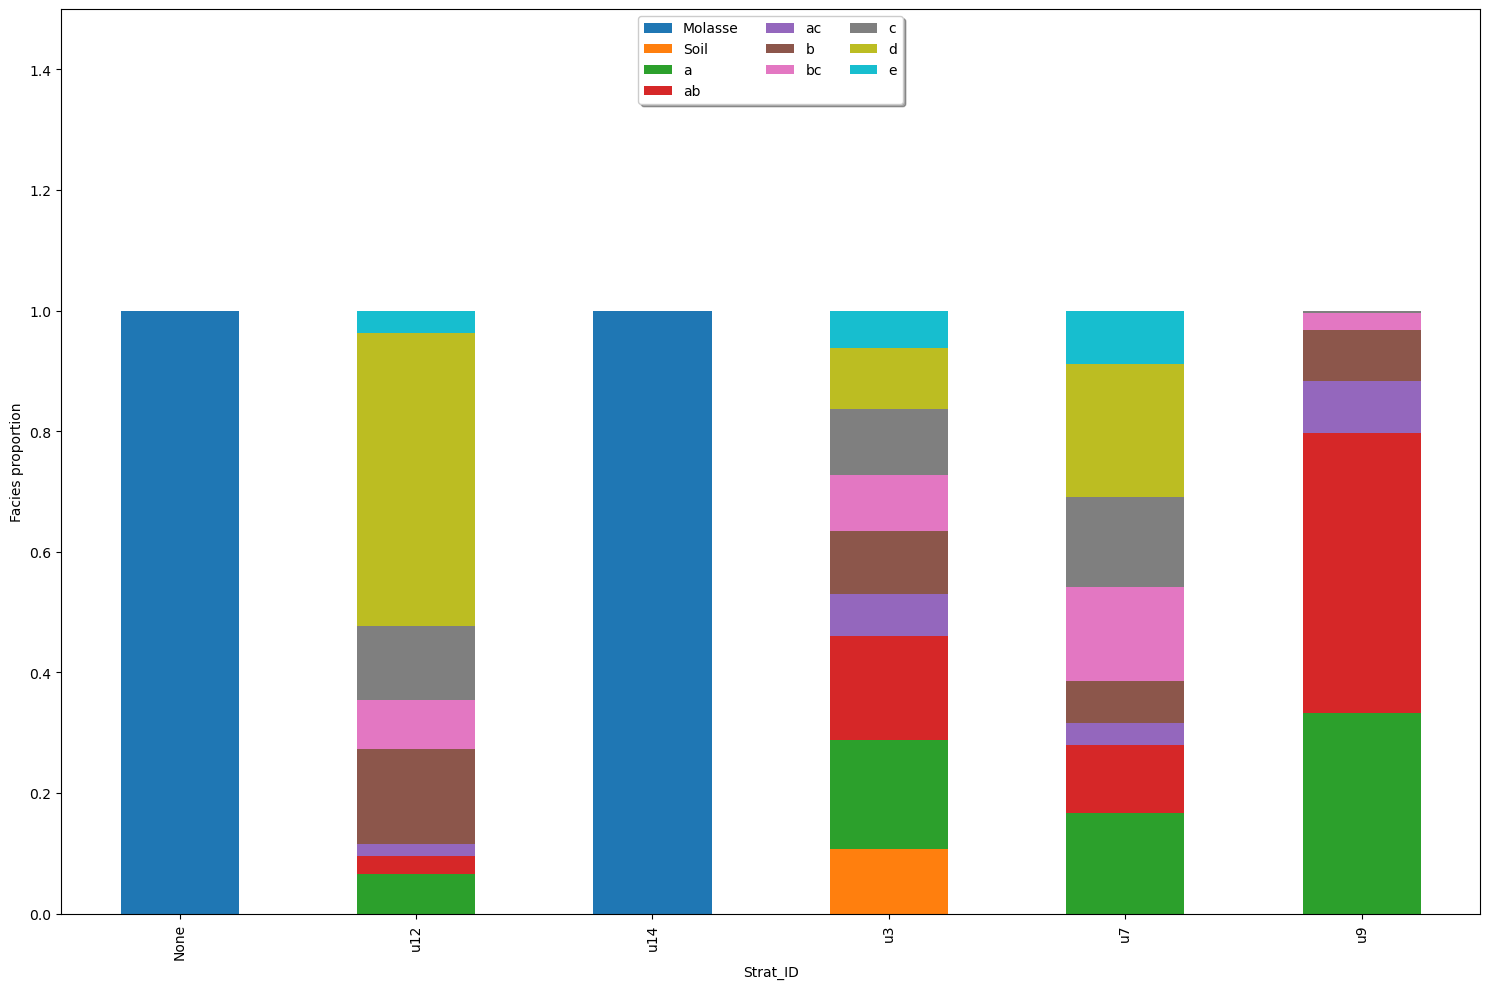

In [17]:
ArchPy.inputs.bhs_analysis(db)

In [18]:
datas = np.array(db) #Vérifier lien entre units et facies
datas

array([['u3', 'ab', 373.6, 373.4],
       ['u3', 'a', 373.4, 372.6],
       ['u3', 'b', 372.6, 364.4],
       ...,
       ['u3', None, 376.1, 374.5],
       ['u3', None, 374.5, 373.0],
       ['u7', None, 373.0, 372.95]], dtype=object)

In [19]:
boreholes = ArchPy.inputs.extract_bhs(df=db, list_bhs=l_bhs, ArchTable=T1)

In [20]:
T1.add_bh(boreholes)

Borehole 19444.0 outside of the simulation zone - not added -
Borehole 18793.0 added
Borehole 19110.0 added
Borehole 18790.0 added
Borehole 19335.0 added
Borehole 19113.0 added
Borehole 18828.0 added
Borehole 19108.0 added
Borehole 19109.0 added
Borehole 19461.0 added
Borehole 18032.0 added
Borehole 18792.0 added
Borehole 18786.0 added
Borehole 19107.0 added
Borehole 19112.0 added
Borehole 19172.0 added
Borehole 18707.0 added
Borehole 18791.0 added
Borehole 18710.0 added
Borehole 18788.0 added
Borehole 19111.0 added
Borehole 19610.0 goes below model limits, borehole 19610.0 depth cut
Borehole 19610.0 added
Borehole 18709.0 added
Borehole 18708.0 added
Borehole 19333.0 added
Borehole 18789.0 added
Borehole 18787.0 added
Borehole 8834.0 added
Borehole 16434.0 goes below model limits, borehole 16434.0 depth cut
Borehole 16434.0 added
Borehole 14059.0 goes below model limits, borehole 14059.0 depth cut
Borehole 14059.0 added
Borehole 1228.0 added
Borehole 4080.0 added
Borehole 13394.0 adde

In [21]:
T1.process_bhs()

##### ORDERING UNITS ##### 
Pile Pile_1: ordering units
Stratigraphic units have been sorted according to order
hierarchical relations set
Multiples boreholes [18793.0, 18792.0] were found inside the same cell, the deepest will be kept
Multiples boreholes [19113.0, 14153.0] were found inside the same cell, the deepest will be kept
Multiples boreholes [19108.0, 14155.0, 14157.0] were found inside the same cell, the deepest will be kept
Multiples boreholes [19109.0, 14154.0] were found inside the same cell, the deepest will be kept
Multiples boreholes [19107.0, 14156.0] were found inside the same cell, the deepest will be kept
Multiples boreholes [18710.0, 16945.0] were found inside the same cell, the deepest will be kept
Multiples boreholes [13394.0, 13393.0] were found inside the same cell, the deepest will be kept
Multiples boreholes [8613.0, 6384.0, 15606.0] were found inside the same cell, the deepest will be kept
Multiples boreholes [8069.0, 6079.0] were found inside the same cell,

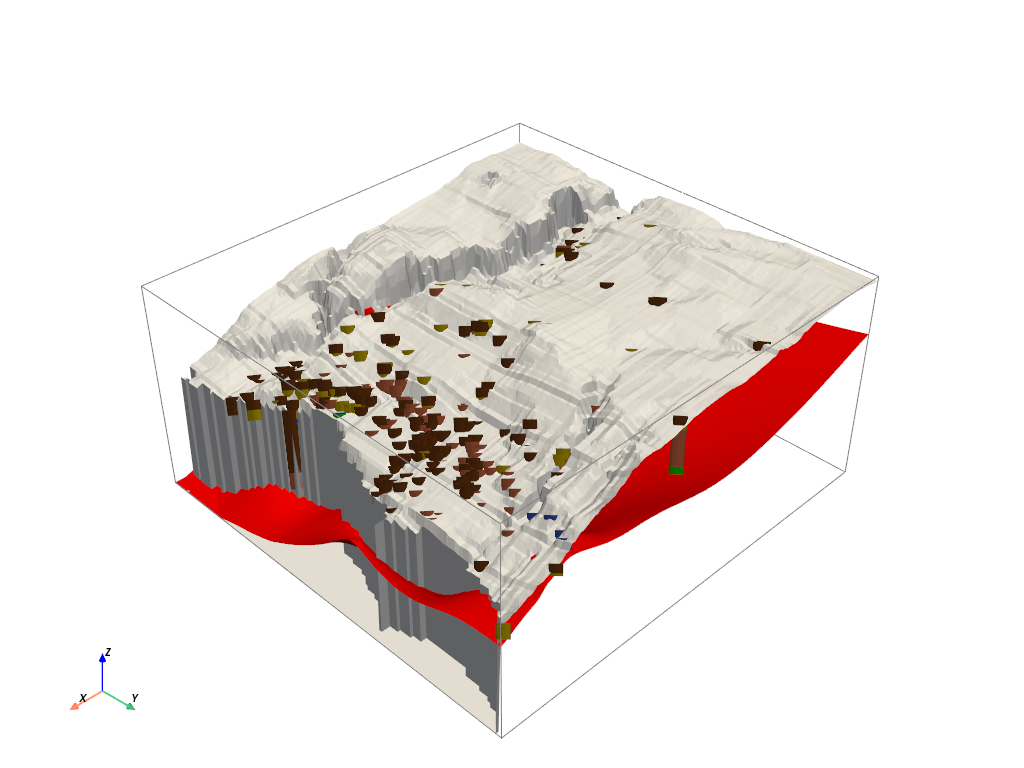

In [22]:
pv.set_jupyter_backend('static')
T1.plot_bhs(v_ex=10, plot_top=True, plot_bot=True)

In [23]:
T1.get_bh(14060).log_facies

[(None, 381.0), (Molasse, 321.0)]

### SURFACE PARAMETERS ESTIMATION ### 

### UNIT : u3 ### 

Not enough data points
Default covmodel added


<Figure size 3200x2400 with 0 Axes>

### UNIT : u7 ### 



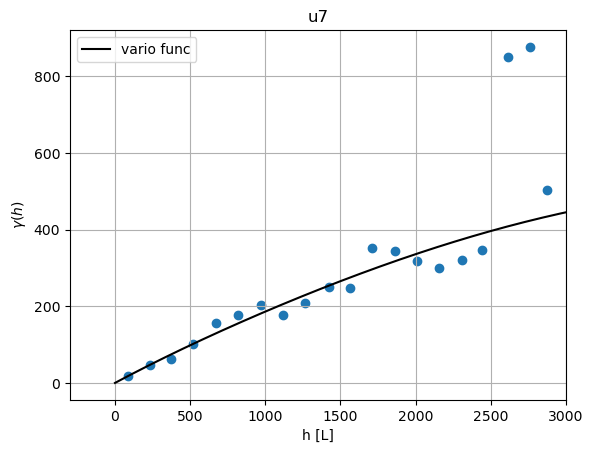

### UNIT : u9 ### 



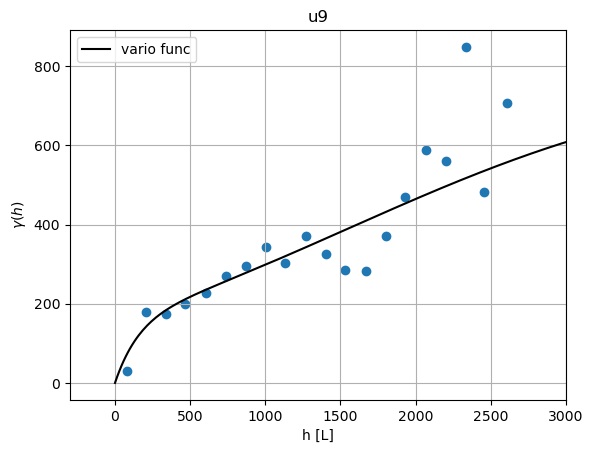

### UNIT : u12 ### 



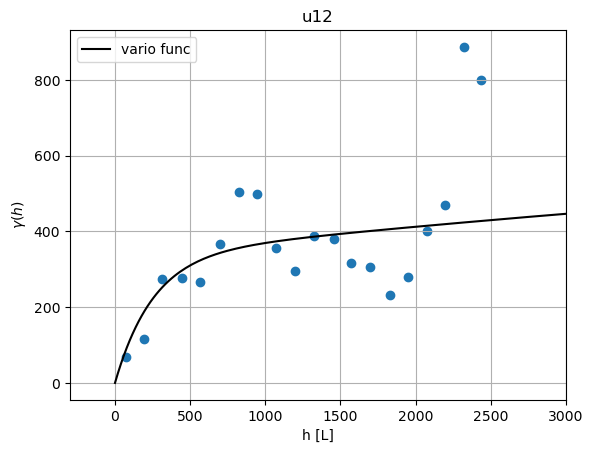

### UNIT : u14 ### 



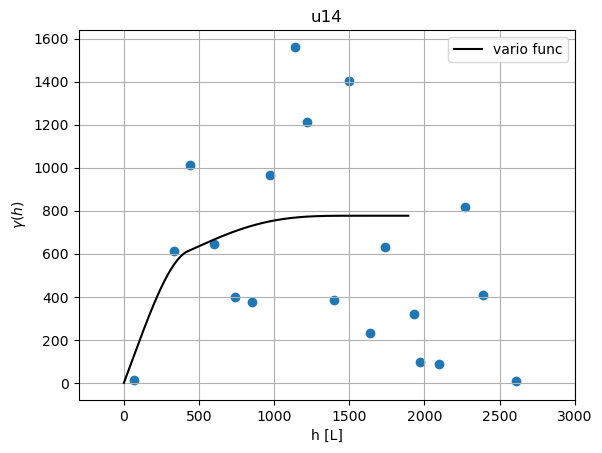

In [24]:
#%matplotlib inline
plt.figure(dpi=500)
T1.estimate_surf_params(auto=True, hmax=3000, npoints_min=5)

In [25]:
T1.process_bhs()

##### ORDERING UNITS ##### 
Pile Pile_1: ordering units
Stratigraphic units have been sorted according to order
hierarchical relations set
Boreholes already processed


In [26]:
T1.compute_surf(10)

########## PILE Pile_1 ##########
Pile Pile_1: ordering units
Stratigraphic units have been sorted according to order

#### COMPUTING SURFACE OF UNIT u14
simulate2D: Geos-Classic running... [VERSION 2.0 / BUILD NUMBER 20240322 / OpenMP 11 thread(s)]
simulate2D: Geos-Classic run complete
u14: time elapsed for computing surface 0.3515491485595703 s

#### COMPUTING SURFACE OF UNIT u12
simulate2D: WARNING: 11 grid cell(s) have both "inequality (min)" and "equality" data: inequlity data has been removed
simulate2D: WARNING: 1 grid cell(s) have both "inequality (max)" and "equality" data: inequlity data has been removed
simulate2D: Geos-Classic running... [VERSION 2.0 / BUILD NUMBER 20240322 / OpenMP 11 thread(s)]
simulate2D: Geos-Classic run complete
u12: time elapsed for computing surface 0.4219043254852295 s

#### COMPUTING SURFACE OF UNIT u9
simulate2D: WARNING: 17 grid cell(s) have both "inequality (min)" and "equality" data: inequlity data has been removed
simulate2D: Geos-Classic runn

In [27]:
T1.compute_facies(5)


### Unit u3: facies simulation with SIS method ####
### Unit u3 - realization 0 ###
### Unit u3 - realization 1 ###
### Unit u3 - realization 2 ###
### Unit u3 - realization 3 ###
### Unit u3 - realization 4 ###
### Unit u3 - realization 5 ###
### Unit u3 - realization 6 ###
### Unit u3 - realization 7 ###
### Unit u3 - realization 8 ###
### Unit u3 - realization 9 ###
Time elapsed 17.28 s

### Unit u7: facies simulation with SIS method ####
### Unit u7 - realization 0 ###
Some errors have been found 
Some facies were found inside units where they shouldn't be 

### List of errors ####
Facies Soil: 8 points
Facies ac: 45 points


### Unit u7 - realization 1 ###
Some errors have been found 
Some facies were found inside units where they shouldn't be 

### List of errors ####
Facies Soil: 5 points
Facies ac: 50 points


### Unit u7 - realization 2 ###
Some errors have been found 
Some facies were found inside units where they shouldn't be 

### List of errors ####
Facies Soil: 4 points


In [28]:
T1.compute_prop(1)

### 50 K property models will be modeled ###
### 1 K models done
### 2 K models done
### 3 K models done
### 4 K models done
### 5 K models done
### 6 K models done
### 7 K models done
### 8 K models done
### 9 K models done
### 10 K models done
### 11 K models done
### 12 K models done
### 13 K models done
### 14 K models done
### 15 K models done
### 16 K models done
### 17 K models done
### 18 K models done
### 19 K models done
### 20 K models done
### 21 K models done
### 22 K models done
### 23 K models done
### 24 K models done
### 25 K models done
### 26 K models done
### 27 K models done
### 28 K models done
### 29 K models done
### 30 K models done
### 31 K models done
### 32 K models done
### 33 K models done
### 34 K models done
### 35 K models done
### 36 K models done
### 37 K models done
### 38 K models done
### 39 K models done
### 40 K models done
### 41 K models done
### 42 K models done
### 43 K models done
### 44 K models done
### 45 K models done
### 46 K models don

In [29]:
#Retrieving results
unit_domains = T1.get_units_domains_realizations().shape
facies_reals = T1.get_facies
K = T1.get_prop("K")

In [30]:
ArchPy.inputs.save_project(T1)

Project saved successfully


True

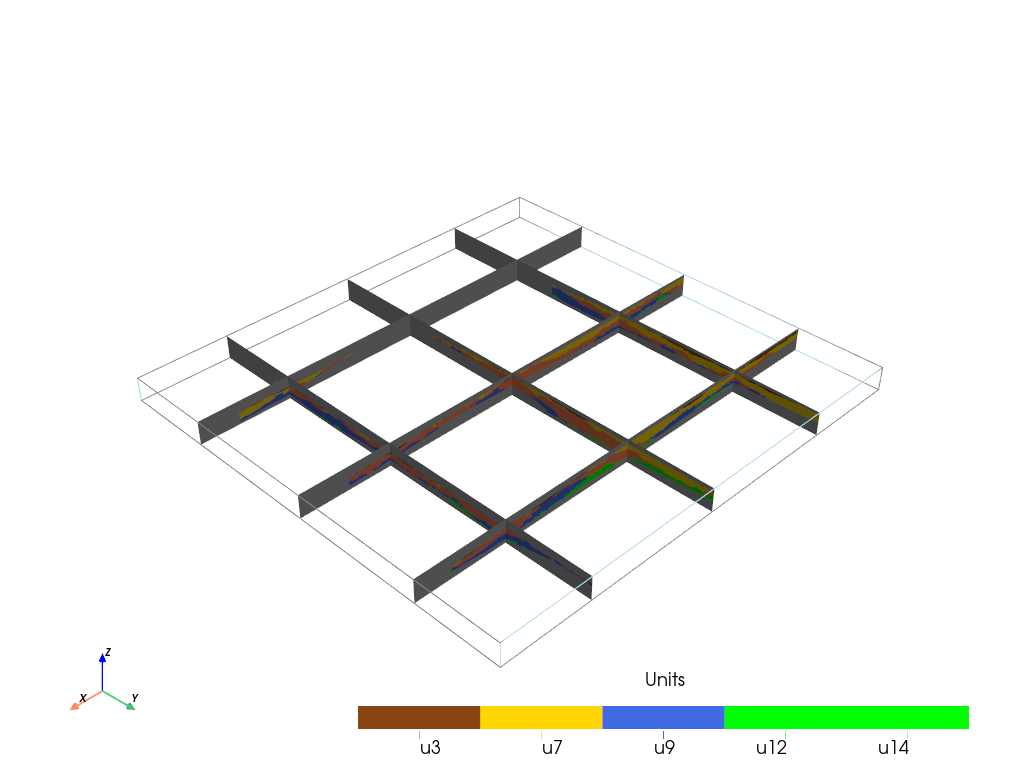

In [31]:
#Plots
pv.set_jupyter_backend("static")
T1.plot_units(iu=0, slicex=(0.2, 0.5, 0.8), slicey=(0.2, 0.5, 0.8))

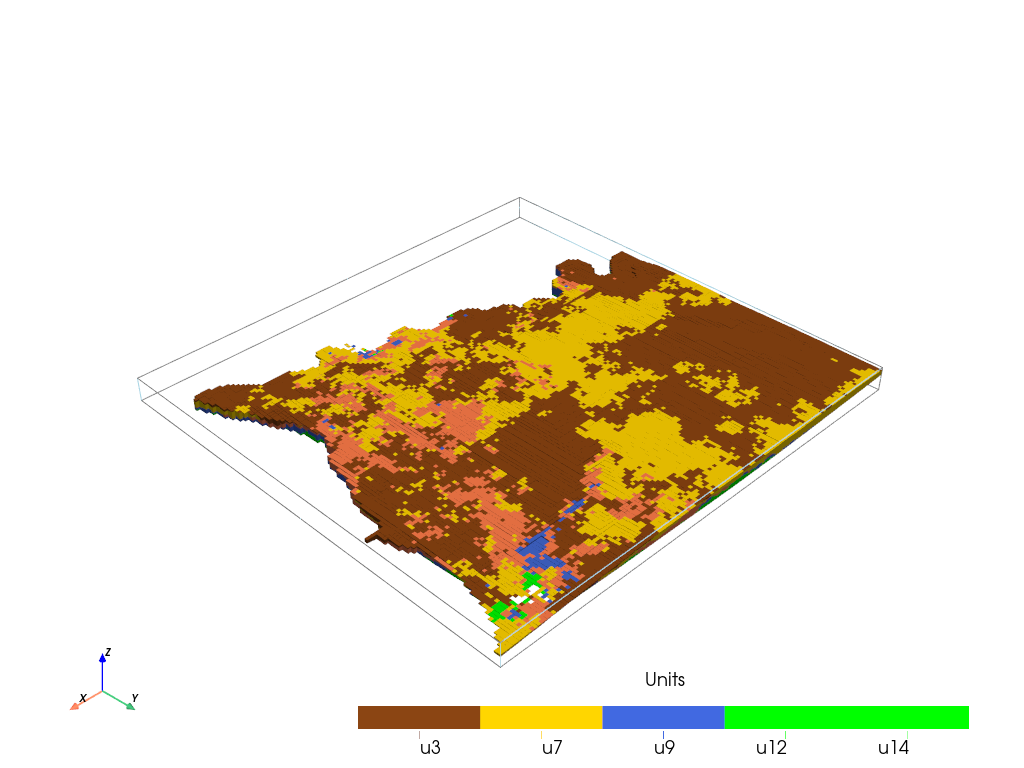

In [32]:
pv.set_jupyter_backend("static")
T1.plot_units(h_level=2)

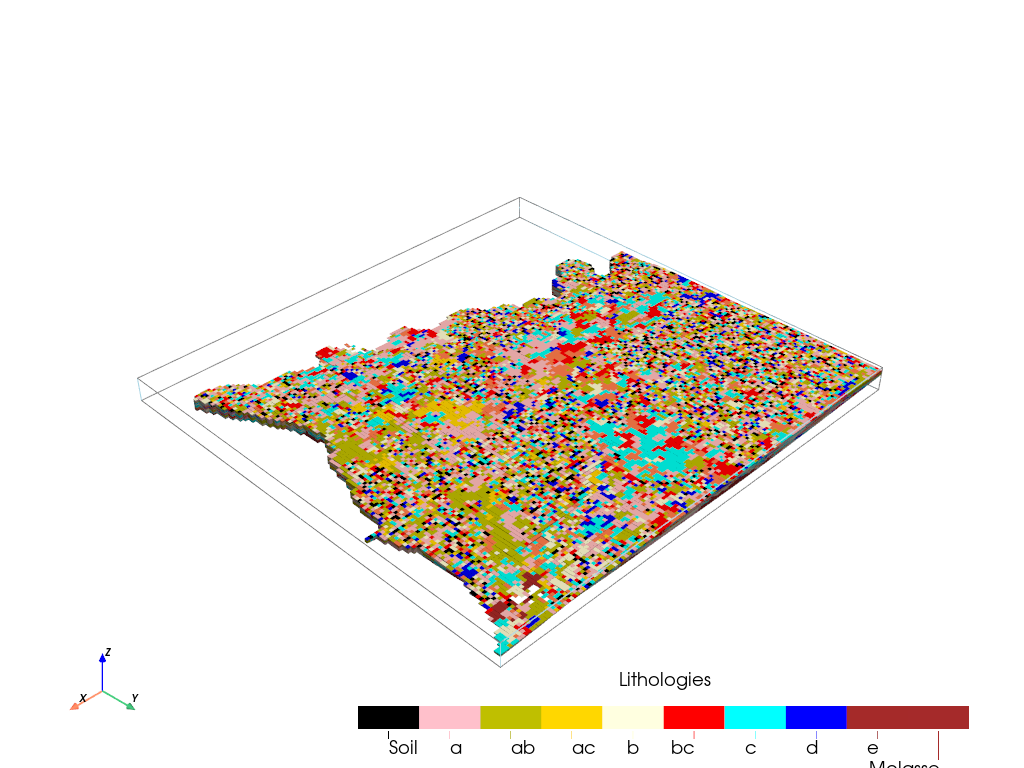

In [33]:
pv.set_jupyter_backend("static")
T1.plot_facies()

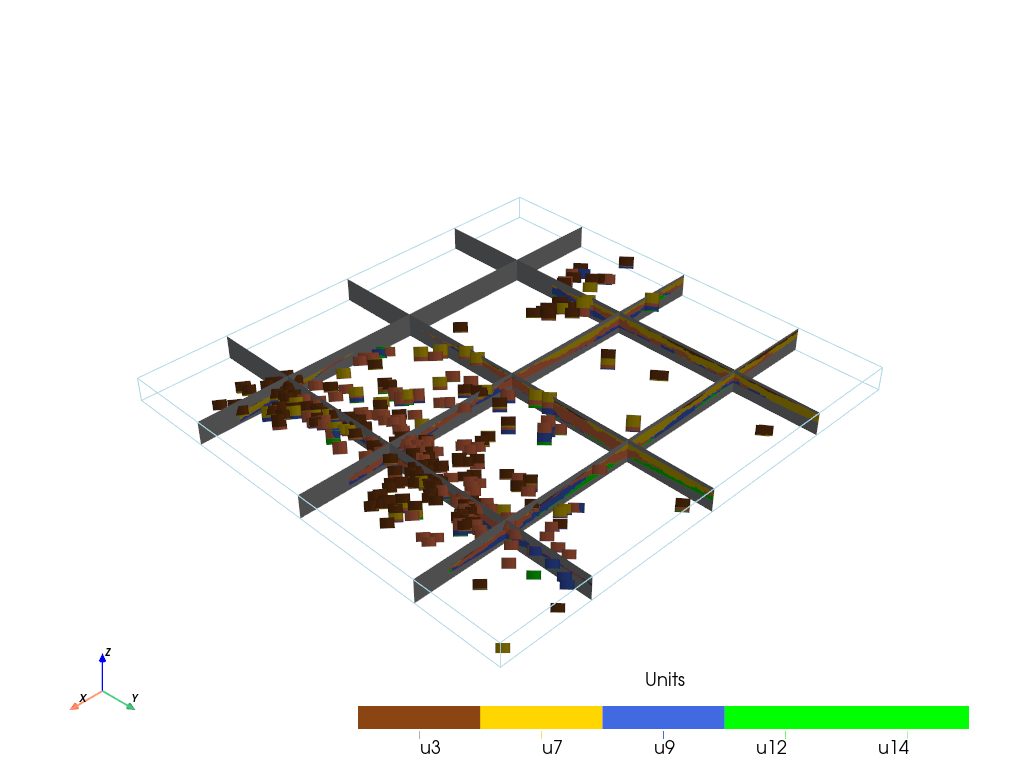

In [34]:
p = pv.Plotter()
v_ex = 1

T1.plot_units(0, v_ex=v_ex, plotter=p, slicex=(0.2, 0.5, 0.8), slicey=(0.2, 0.5, 0.8))
T1.plot_bhs(plotter=p, v_ex=v_ex)
p.show()

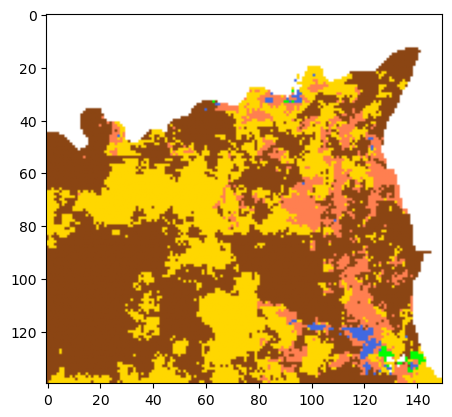

In [35]:
geol_map = T1.compute_geol_map(0, color=True)
plt.imshow(geol_map)
plt.show()

In [36]:
def get_Ivalues(T1, unit, facies, iu = 0):

    """
    Return indicator values (1 if present, 0 if not) of hard data facies contains in given unit
    """

    x, fa_values = T1.hd_fa_in_unit(unit, iu=iu)  # get the data
    x = np.array(x)
    fa_values = np.array(fa_values)

    # setup values

    v = fa_values.copy()

    v[v != facies.ID] = 0

    v[v == facies.ID] = 1

    return x, v

In [37]:
def estimate_SIS_covmodel(unit, arch_table, facies, covmodel, cm_fitted_3D=None, iu=0, ndata_min = 100,
                          ignore_factor = 1, hmax=np.nan, ncla=15, bounds=(), plot_varExp=True, alpha_loc_func = None,
                            **kwargs):
    """
    Estimate a 3D indicator covmodel according to data of a facies
    kwargs : arguments for variogramExp3D
    """
    kwargs_def = {"tol_dist":(10, 10, 5), "tol_angle":(45, 45, 10), "hmax_var" : (hmax, hmax, hmax),
    "ncla" : (ncla, ncla, ncla), "cla_center" : (None, None, None), "cla_length" : (None, None, None)}

    for k, val in kwargs_def.items():
        if k not in kwargs.keys():
            kwargs[k] = val
            
    #first get x position and indicator values (0 or 1)
    x_pos,v = get_Ivalues(arch_table, unit, facies, iu)
    ndata = len(v)

    if ignore_factor > 1:
        ndata_to_keep = 1/ignore_factor * ndata
        ind = np.random.choice(np.arange(ndata),size=ndata_to_keep)
        x_pos = x_pos[ind]
        v = v[ind]

    if ndata < ndata_min:
        print("Too few points")
        return None
        
    #2nd estimate covmodel
    if not plot_varExp:
        make_plot = True
        
    # cm_fitted_3D, popt = gcm.covModel3D_fit(x_pos,np.array(v),covmodel,make_plot=False,
    #                                     bounds = bounds,hmax = hmax, alpha_loc_func = alpha_loc_func)

    #plot to validate
    if plot_varExp:
        (hexp1, gexp1, cexp1),(hexp2, gexp2, cexp2),(hexp3, gexp3, cexp3) = gcm.variogramExp3D(x_pos,v,
                                                                                               alpha=cm_fitted_3D.alpha,
                                                                                               beta=cm_fitted_3D.beta,
                                                                                               gamma=cm_fitted_3D.gamma,
                                                                                tol_dist=kwargs["tol_dist"],tol_angle=kwargs["tol_angle"],
                                                                                               make_plot=False,hmax = kwargs["hmax_var"],ncla = kwargs["ncla"],
                                                                                               cla_length = kwargs["cla_length"], cla_center = kwargs["cla_center"],
                                                                                               alpha_loc_func = alpha_loc_func)
        
        plt.subplots(1,3,figsize=(16,8))
        plt.suptitle(f'Unit: {str(unit)}, facies: {str(facies)}')
        
        plt.subplot(1,3,1)
        geone.covModel.plot_variogramExp1D(hexp1, gexp1, cexp1, c='red', label='vario exp')
        cm_fitted_3D.plot_model_one_curve(vario=True, main_axis=1, hmax=0.8*np.nanmax(hexp1), c='red', label='vario opt')
        plt.legend()
        plt.title("along x'''")

        plt.subplot(1,3,2)
        geone.covModel.plot_variogramExp1D(hexp2, gexp2, cexp2, c='green', label='vario exp')
        cm_fitted_3D.plot_model_one_curve(vario=True, main_axis=2, hmax=0.8*np.nanmax(hexp2), c='green', label='vario opt')
        plt.legend()
        plt.title("along y'''")

        plt.subplot(1,3,3)
        geone.covModel.plot_variogramExp1D(hexp3, gexp3, cexp3, c='blue', label='vario exp')
        cm_fitted_3D.plot_model_one_curve(vario=True, main_axis=3, hmax=0.8*np.nanmax(hexp3), c='blue', label='vario opt')
        plt.legend()
        plt.title("along z'''")
        plt.show()
        
    return cm_fitted_3D

In [38]:
runned = True

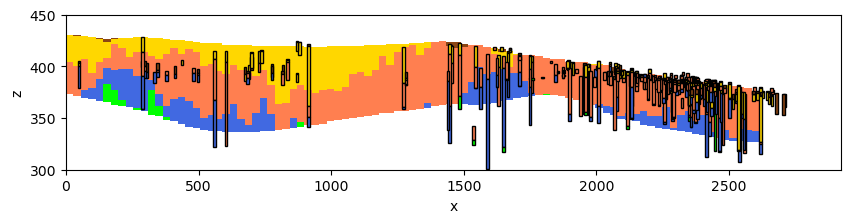

In [39]:
#pv.set_jupyter_backend("static")

i_cs = 5

T1.plot_cross_section([(X0+20,Y0 + i_cs*(Y1-Y0)/10),(X1-20,Y0 + i_cs*(Y1-Y0)/10)],ratio_aspect=5,typ='units',dist_max=1000, width=10)
#plt.title('Cross-section W-E : units')
plt.xlabel('x')
plt.ylabel('z')
plt.show()

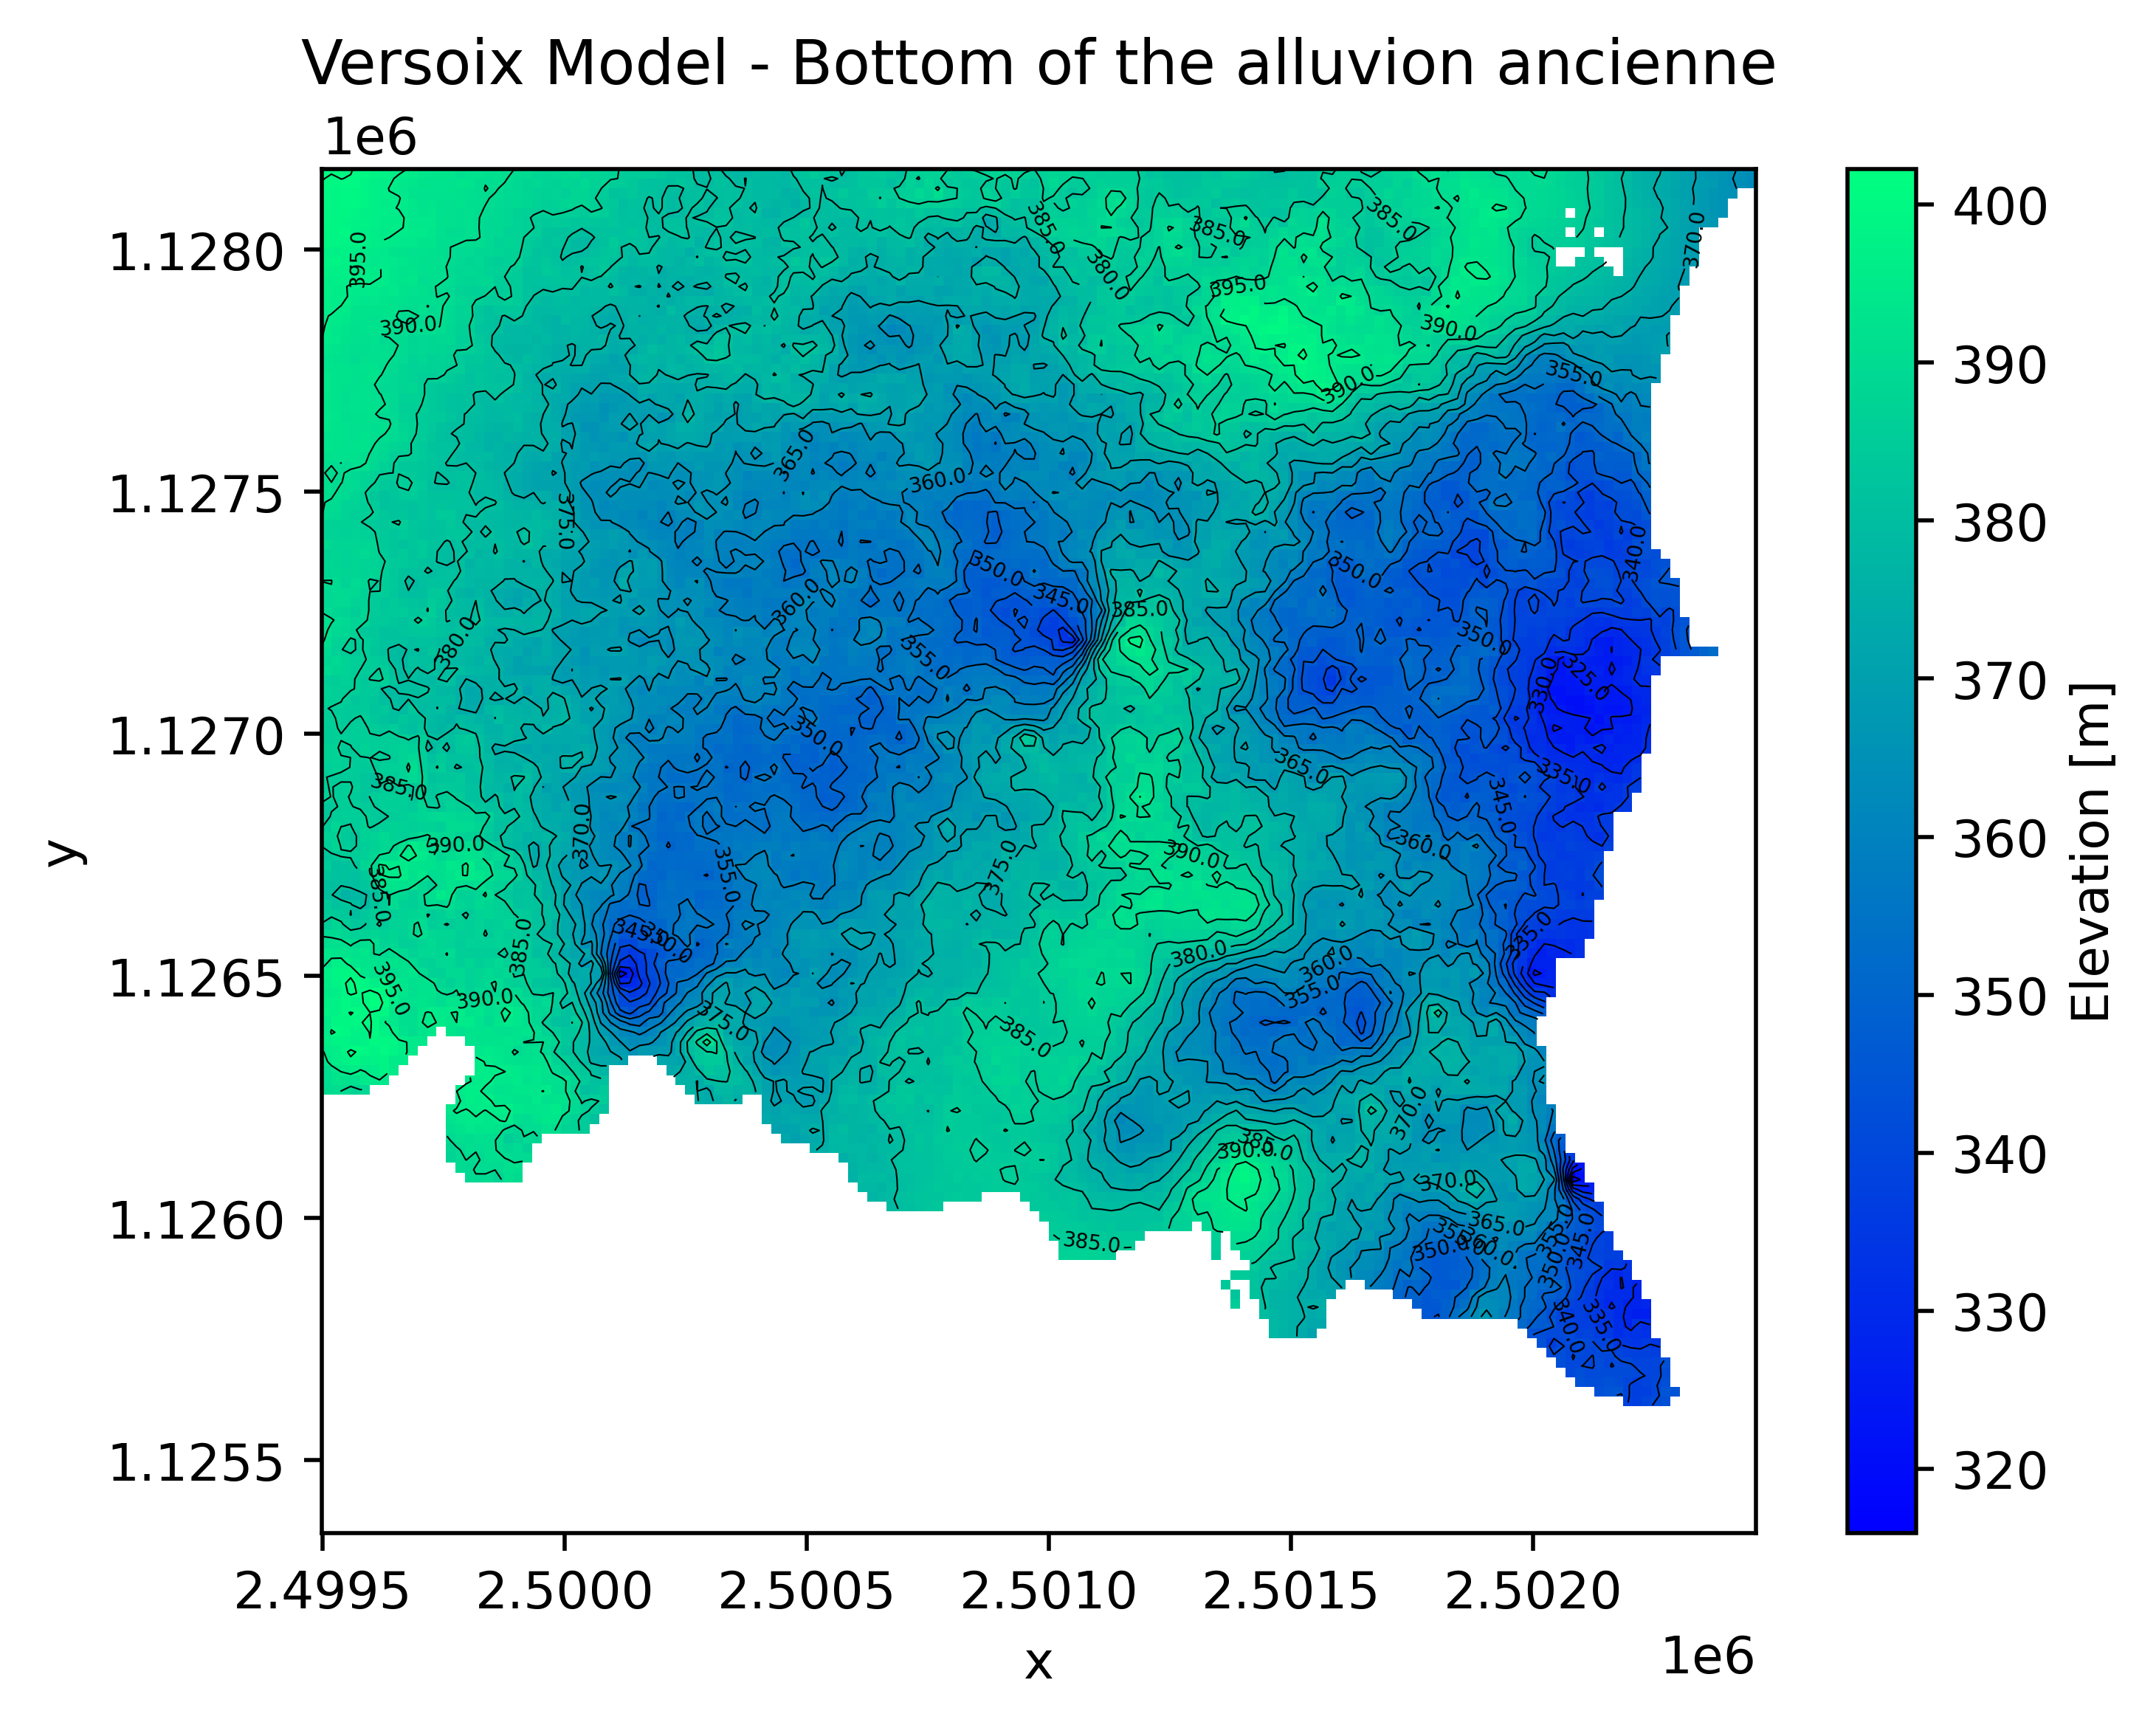

In [40]:
surf = T1.get_surfaces_unit(T1.get_unit('u9'),typ='bot')
surf_0 = np.nanmean(surf, axis=0)
plt.figure(dpi=500)
plt.imshow(surf_0, origin="lower", extent = [X0,X1,Y0,Y1], cmap='winter')
plt.colorbar(label='Elevation [m]')
contour = plt.contour(surf_0, colors="k", levels=20, alpha=1, linewidths=0.3, extent = [X0,X1,Y0,Y1])
plt.clabel(contour, fmt="%.1f", colors="k", fontsize=4)
plt.title(f'Versoix Model - Bottom of the alluvion ancienne')
plt.xlabel('x')
plt.ylabel('y')
plt.show()